In [50]:
from sklearn.datasets import make_regression
import pandas as pd
import numpy as np

import plotly.express as px
import plotly.graph_objects as go

from sklearn.metrics import mean_absolute_error,mean_squared_error,root_mean_squared_error,r2_score

In [52]:
X,y=make_regression(n_samples=150,n_features=2,n_targets=1,n_informative=2,noise=50)  # this is predefied dataset to Regression 

In [53]:
df=pd.DataFrame({'features1':X[:,0],'features2':X[:,1],'target':y})
df.head()

,features1,features2,target
0,-1.209045,-1.552015,-248.157698
1,-0.761194,0.179905,-116.096777
2,-0.698178,-2.291274,-278.622434
3,-1.723718,-0.572532,-129.172928
4,-1.044278,-0.824034,-177.465700


In [54]:
df.shape

(150, 3)

# PLot in 3D

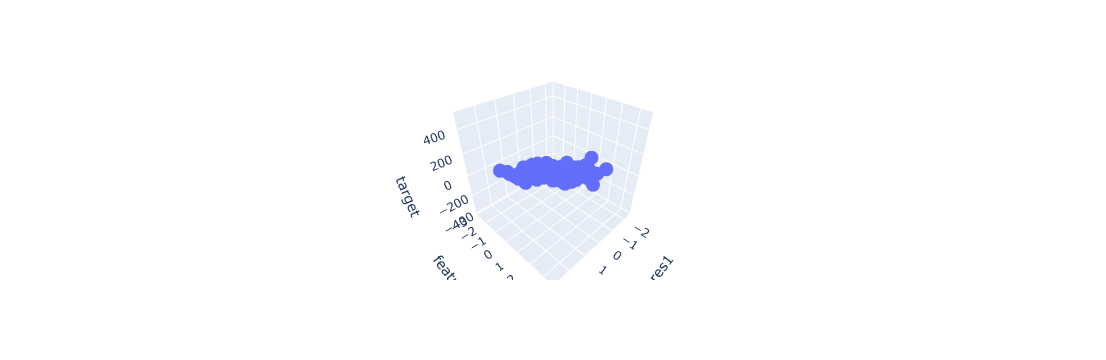

In [55]:
fig=px.scatter_3d(df,x='features1',y='features2',z='target')
fig.show()

In [56]:
from sklearn.model_selection import train_test_split

In [57]:
X_train,X_test,y_train,y_test=train_test_split(df.iloc[:,0:2],df.iloc[:,-1],test_size=0.2)

In [58]:
X_train.head()

,features1,features2
81,0.767092,-0.164166
115,-0.163705,0.431122
43,0.484026,0.423650
134,0.666506,-0.188377
58,-1.139647,-0.283776


In [59]:
lr=LinearRegression()

In [60]:
lr.fit(X_train,y_train)

LinearRegression()

In [61]:
y_pred=lr.predict(X_test)

In [62]:
print("MSE :",mean_squared_error(y_test,y_pred))
print("MAE :",mean_absolute_error(y_test,y_pred))
print("RMSE :",root_mean_squared_error(y_test,y_pred))
print("R2 Score :",r2_score(y_test,y_pred))

MSE : 1584.3363046844322
MAE : 29.006342354428853
RMSE : 39.803722246599406
R2 Score : 0.9452078602271217


# plot in Hyperplane sheet

In [67]:
x=np.linspace(-5,5,10)
y=np.linspace(-5,5,10)
z=np.linspace(-5,5,10)
xGrid,yGrid,=np.meshgrid(y,x)
final=np.vstack((xGrid.ravel().reshape(1,100),yGrid.ravel().reshape(1,100))).T

z_final=lr.predict(final).reshape(10,10)

z=z_final



C:\Users\91886\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning:

X does not have valid feature names, but LinearRegression was fitted with feature names



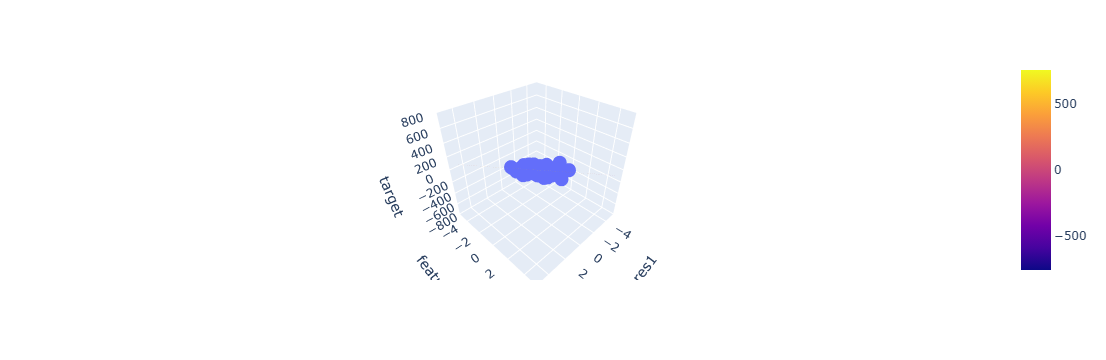

In [68]:
fig=px.scatter_3d(df,x='features1',y='features2',z='target')
fig.add_trace(go.Surface(x=x,y=y,z=z))
fig.show()

In [69]:
lr.coef_

array([84.7546496 , 66.89083016])

In [70]:
lr.intercept_

np.float64(-2.920822297166799)